In [1]:
import pandas as pd
import os
from utils.eda_utils import EDAUtils
import boto3
import numpy as np

import re
from io import BytesIO
from urllib.parse import urlparse
from typing import List, Optional, Tuple

from botocore.config import Config
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
from functools import partial

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
CONFIG_DIR_PATH = os.path.join(ROOT_DIR_PATH, "config")

In [4]:
edau = EDAUtils()

In [ ]:
print(SSP_DIR_PATH)

In [5]:
run_id = "100k"

In [6]:
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, run_id)

In [7]:
SIM_PARQUET_DIR_PATH = os.path.join(SIMULATION_DIR_PATH, "parquets")

In [ ]:
SIM_PARQUET_DIR_PATH

In [ ]:
SIM_PARQUET_DIR_PATH

In [8]:
# Load a single parquet file
decomposed_df = pd.read_parquet(os.path.join(SIM_PARQUET_DIR_PATH, "decomposed_combined.parquet"))
cb_df = pd.read_parquet(os.path.join(SIM_PARQUET_DIR_PATH, "combined_cb_outputs.parquet"))
lsu_data = pd.read_parquet(os.path.join(SIM_PARQUET_DIR_PATH, "combined_jobs_outputs.parquet"))

In [9]:
# 2) Define your fuels and sectors
relevant_fuels = ['biomass', 
                    'coal', 
                    'coke', 
                    'diesel', 
                    'electricity',
                    'furnace_gas',
                    'gasoline', 
                    'hydrocarbon_gas_liquids',
                    'hydrogen',
                    'kerosene',
                    'natural_gas',
                    'natural_gas_liquid',
                    'oil']

sectors = ['agriculture_and_livestock',
           'cement',
           'chemicals',
           'electronics',
           'glass',
           'lime_and_carbonite',
           'metals',
           'mining',
           'other_product_manufacturing',
           'paper',
           'plastic',
           'recycled_glass',
           'recycled_metals',
           'recycled_paper',
           'recycled_plastic',
           'recycled_rubber_and_leather',
           'recycled_textiles',
           'recycled_wood',
           'rubber_and_leather',
           'textiles',
           'wood']

In [10]:
# 4) Industrial cost parameters
capex_industrial_electricity = 92666.6 * 21
capex_industrial_other       = 92666.6 * 12
opex_industrial_electricity  = 92666.6 * 2.5
opex_industrial_other        = 92666.6 * 4.5
capex_multiplier_efficiency = 10000000
opex_multiplier_efficiency = 0

In [11]:
# 5) Loop over fuels and sectors
# Use the original dataframe directly
# Initialize results dataframe
ind_fuel_demand_by_sector = pd.DataFrame({
    'primary_id': decomposed_df['primary_id'],
    'time_period': decomposed_df['time_period']
}, index=decomposed_df.index)

# Helper alias for tricky fuel names
alias = {
    'natural_gas_liquid': ['natural_gas_liquid', 'natural_gas_liquids'],
    'biomass': ['biomass', 'solid_biomass'],   # <-- added
}

for fuel in relevant_fuels:
    fuel_keys = alias.get(fuel, [fuel])  # use aliases everywhere for this fuel

    # ------------------------------------------------------------
    # ENTc (fuel-only) — handled OUTSIDE sector loop
    # ------------------------------------------------------------
    entc_found_col = None
    for k in fuel_keys:
        cand = f'energy_demand_enfu_subsector_total_pj_entc_fuel_{k}'
        if cand in decomposed_df.columns:
            entc_found_col = cand
            break
    if entc_found_col is not None:
        ind_fuel_demand_by_sector[entc_found_col] = decomposed_df[entc_found_col]

    # ------------------------------------------------------------
    # Efficiency column (accept any alias)
    # ------------------------------------------------------------
    eff_cols = [
        c for c in decomposed_df.columns
        if any(c.startswith(f'efficfactor_enfu_industrial_energy_fuel_{k}') for k in fuel_keys)
    ]
    if not eff_cols:
        continue
    fuel_efficiency = decomposed_df[eff_cols[0]]

    # ------------------------------------------------------------
    # Sector loop (unchanged logic; now alias-aware for fractions)
    # ------------------------------------------------------------
    for sector in sectors:
        sector_dem_cols = [c for c in decomposed_df.columns
                           if f'energy_demand_inen_{sector}' in c]
        sector_fuel_fraction_cols = [
            c for c in decomposed_df.columns
            if any(f'frac_inen_energy_{sector}_{k}' in c for k in fuel_keys)
        ]

        if sector_dem_cols and sector_fuel_fraction_cols:
            sector_total_demand = decomposed_df[sector_dem_cols[0]]
            sector_fuel_fraction = decomposed_df[sector_fuel_fraction_cols[0]]

            has_any_demand = ((sector_fuel_fraction * sector_total_demand).fillna(0) != 0).any()
            if has_any_demand or fuel == 'electricity':
                sector_fuel_demand = sector_fuel_fraction * sector_total_demand
                ind_fuel_demand_by_sector[f'energy_demand_{sector}_{fuel}'] = sector_fuel_demand

                # CAPEX/OPEX
                if fuel == 'electricity':
                    ind_fuel_demand_by_sector[f'energy_demand_capex_{sector}_{fuel}'] = (
                        sector_fuel_demand * capex_industrial_electricity
                    )
                    ind_fuel_demand_by_sector[f'energy_demand_opex_{sector}_{fuel}'] = (
                        sector_fuel_demand * opex_industrial_electricity
                    )
                else:
                    ind_fuel_demand_by_sector[f'energy_demand_capex_{sector}_{fuel}'] = (
                        sector_fuel_demand * capex_industrial_other
                    )
                    ind_fuel_demand_by_sector[f'energy_demand_opex_{sector}_{fuel}'] = (
                        sector_fuel_demand * opex_industrial_other
                    )

                # Fuel consumed + deltas
                sector_fuel_consumed = sector_fuel_demand / fuel_efficiency
                sector_fuel_consumed_baseline = (
                    sector_fuel_consumed.groupby(decomposed_df['primary_id']).transform('first')
                )
                sector_change_in_fuel_consumed = sector_fuel_consumed_baseline - sector_fuel_consumed
                ind_fuel_demand_by_sector[f'efficiency_energy_saving_{sector}_{fuel}'] = sector_change_in_fuel_consumed
                ind_fuel_demand_by_sector[f'efficiency_capex_{sector}_{fuel}'] = (
                    sector_change_in_fuel_consumed * capex_multiplier_efficiency
                )
                ind_fuel_demand_by_sector[f'efficiency_opex_{sector}_{fuel}'] = (
                    sector_change_in_fuel_consumed * opex_multiplier_efficiency
                )

C:\Users\nasta\AppData\Local\Temp\ipykernel_49268\2272902701.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ind_fuel_demand_by_sector[f'energy_demand_{sector}_{fuel}'] = sector_fuel_demand
C:\Users\nasta\AppData\Local\Temp\ipykernel_49268\2272902701.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ind_fuel_demand_by_sector[f'energy_demand_capex_{sector}_{fuel}'] = (
C:\Users\nasta\AppData\Local\Temp\ipykernel_49268\2272902701.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

In [12]:
del(decomposed_df)

In [14]:
ind_fuel_demand_by_sector_100k = ind_fuel_demand_by_sector
del(ind_fuel_demand_by_sector)

In [15]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")
CONFIG_DIR_PATH = os.path.join(ROOT_DIR_PATH, "config")

In [16]:
run_id="sisepuede_run_2025-09-18t09;19;22.726476"

In [17]:
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, run_id)

In [18]:
attr_primary_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "ATTRIBUTE_PRIMARY.csv"))

In [19]:
wide_inputs_outputs_df = pd.read_csv(os.path.join(SIMULATION_DIR_PATH, "sisepuede_results_IDE_2025-09-18t09;19;22.726476.csv"))

In [20]:
attr_primary_df = attr_primary_df[attr_primary_df["strategy_id"].isin([6004])]

In [21]:
wide_inputs_outputs_df = wide_inputs_outputs_df[wide_inputs_outputs_df["primary_id"].isin(attr_primary_df["primary_id"].unique())]

In [22]:
# 2) Define your fuels and sectors
relevant_fuels = ['biomass', 
                    'coal', 
                    'coke', 
                    'diesel', 
                    'electricity',
                    'furnace_gas',
                    'gasoline', 
                    'hydrocarbon_gas_liquids',
                    'hydrogen',
                    'kerosene',
                    'natural_gas',
                    'natural_gas_liquid',
                    'oil']

sectors = ['agriculture_and_livestock',
           'cement',
           'chemicals',
           'electronics',
           'glass',
           'lime_and_carbonite',
           'metals',
           'mining',
           'other_product_manufacturing',
           'paper',
           'plastic',
           'recycled_glass',
           'recycled_metals',
           'recycled_paper',
           'recycled_plastic',
           'recycled_rubber_and_leather',
           'recycled_textiles',
           'recycled_wood',
           'rubber_and_leather',
           'textiles',
           'wood']

In [23]:
# 4) Industrial cost parameters
capex_industrial_electricity = 92666.6 * 21
capex_industrial_other       = 92666.6 * 12
opex_industrial_electricity  = 92666.6 * 2.5
opex_industrial_other        = 92666.6 * 4.5
capex_multiplier_efficiency = 10000000
opex_multiplier_efficiency = 0

In [24]:
# 5) Loop over fuels and sectors
# Use the original dataframe directly
# Initialize results dataframe
ind_fuel_demand_by_sector = pd.DataFrame({
    'primary_id': wide_inputs_outputs_df['primary_id'],
    'time_period': wide_inputs_outputs_df['time_period']
}, index=wide_inputs_outputs_df.index)

# Helper alias for tricky fuel names
alias = {
    'natural_gas_liquid': ['natural_gas_liquid', 'natural_gas_liquids'],
    'biomass': ['biomass', 'solid_biomass'],   # <-- added
}

for fuel in relevant_fuels:
    fuel_keys = alias.get(fuel, [fuel])  # use aliases everywhere for this fuel

    # ------------------------------------------------------------
    # ENTc (fuel-only) — handled OUTSIDE sector loop
    # ------------------------------------------------------------
    entc_found_col = None
    for k in fuel_keys:
        cand = f'energy_demand_enfu_subsector_total_pj_entc_fuel_{k}'
        if cand in wide_inputs_outputs_df.columns:
            entc_found_col = cand
            break
    if entc_found_col is not None:
        ind_fuel_demand_by_sector[entc_found_col] = wide_inputs_outputs_df[entc_found_col]

    # ------------------------------------------------------------
    # Efficiency column (accept any alias)
    # ------------------------------------------------------------
    eff_cols = [
        c for c in wide_inputs_outputs_df.columns
        if any(c.startswith(f'efficfactor_enfu_industrial_energy_fuel_{k}') for k in fuel_keys)
    ]
    if not eff_cols:
        continue
    fuel_efficiency = wide_inputs_outputs_df[eff_cols[0]]

    # ------------------------------------------------------------
    # Sector loop (unchanged logic; now alias-aware for fractions)
    # ------------------------------------------------------------
    for sector in sectors:
        sector_dem_cols = [c for c in wide_inputs_outputs_df.columns
                           if f'energy_demand_inen_{sector}' in c]
        sector_fuel_fraction_cols = [
            c for c in wide_inputs_outputs_df.columns
            if any(f'frac_inen_energy_{sector}_{k}' in c for k in fuel_keys)
        ]

        if sector_dem_cols and sector_fuel_fraction_cols:
            sector_total_demand = wide_inputs_outputs_df[sector_dem_cols[0]]
            sector_fuel_fraction = wide_inputs_outputs_df[sector_fuel_fraction_cols[0]]

            has_any_demand = ((sector_fuel_fraction * sector_total_demand).fillna(0) != 0).any()
            if has_any_demand or fuel == 'electricity':
                sector_fuel_demand = sector_fuel_fraction * sector_total_demand
                ind_fuel_demand_by_sector[f'energy_demand_{sector}_{fuel}'] = sector_fuel_demand

                # CAPEX/OPEX
                if fuel == 'electricity':
                    ind_fuel_demand_by_sector[f'energy_demand_capex_{sector}_{fuel}'] = (
                        sector_fuel_demand * capex_industrial_electricity
                    )
                    ind_fuel_demand_by_sector[f'energy_demand_opex_{sector}_{fuel}'] = (
                        sector_fuel_demand * opex_industrial_electricity
                    )
                else:
                    ind_fuel_demand_by_sector[f'energy_demand_capex_{sector}_{fuel}'] = (
                        sector_fuel_demand * capex_industrial_other
                    )
                    ind_fuel_demand_by_sector[f'energy_demand_opex_{sector}_{fuel}'] = (
                        sector_fuel_demand * opex_industrial_other
                    )

                # Fuel consumed + deltas
                sector_fuel_consumed = sector_fuel_demand / fuel_efficiency
                sector_fuel_consumed_baseline = (
                    sector_fuel_consumed.groupby(wide_inputs_outputs_df['primary_id']).transform('first')
                )
                sector_change_in_fuel_consumed = sector_fuel_consumed_baseline - sector_fuel_consumed
                ind_fuel_demand_by_sector[f'efficiency_energy_saving_{sector}_{fuel}'] = sector_change_in_fuel_consumed
                ind_fuel_demand_by_sector[f'efficiency_capex_{sector}_{fuel}'] = (
                    sector_change_in_fuel_consumed * capex_multiplier_efficiency
                )
                ind_fuel_demand_by_sector[f'efficiency_opex_{sector}_{fuel}'] = (
                    sector_change_in_fuel_consumed * opex_multiplier_efficiency
                )

C:\Users\nasta\AppData\Local\Temp\ipykernel_49268\2033961771.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ind_fuel_demand_by_sector[f'energy_demand_{sector}_{fuel}'] = sector_fuel_demand
C:\Users\nasta\AppData\Local\Temp\ipykernel_49268\2033961771.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ind_fuel_demand_by_sector[f'energy_demand_capex_{sector}_{fuel}'] = (
C:\Users\nasta\AppData\Local\Temp\ipykernel_49268\2033961771.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

In [25]:
ind_fuel_demand_by_sector_1k = ind_fuel_demand_by_sector

In [27]:
print('100k dimensions: ' ,ind_fuel_demand_by_sector_100k.shape)
print('1k dimensions: ', ind_fuel_demand_by_sector_1k.shape)

100k dimensions:  (2899797, 543)
1k dimensions:  (27956, 531)


In [28]:
columns_100k = list(ind_fuel_demand_by_sector_100k.columns)
columns_1k = list(ind_fuel_demand_by_sector_1k.columns)

missing_from_100k = [value for value in columns_100k if value not in columns_1k]
missing_from_1k = [value for value in columns_1k if value not in columns_100k]

In [29]:
print(missing_from_100k)

['energy_demand_agriculture_and_livestock_biomass', 'energy_demand_capex_agriculture_and_livestock_biomass', 'energy_demand_opex_agriculture_and_livestock_biomass', 'efficiency_energy_saving_agriculture_and_livestock_biomass', 'efficiency_capex_agriculture_and_livestock_biomass', 'efficiency_opex_agriculture_and_livestock_biomass', 'energy_demand_glass_biomass', 'energy_demand_capex_glass_biomass', 'energy_demand_opex_glass_biomass', 'efficiency_energy_saving_glass_biomass', 'efficiency_capex_glass_biomass', 'efficiency_opex_glass_biomass', 'energy_demand_wood_biomass', 'energy_demand_capex_wood_biomass', 'energy_demand_opex_wood_biomass', 'efficiency_energy_saving_wood_biomass', 'efficiency_capex_wood_biomass', 'efficiency_opex_wood_biomass', 'energy_demand_glass_coal', 'energy_demand_capex_glass_coal', 'energy_demand_opex_glass_coal', 'efficiency_energy_saving_glass_coal', 'efficiency_capex_glass_coal', 'efficiency_opex_glass_coal', 'energy_demand_wood_coal', 'energy_demand_capex_woo

In [30]:
missing_from_100k

['energy_demand_agriculture_and_livestock_biomass',
 'energy_demand_capex_agriculture_and_livestock_biomass',
 'energy_demand_opex_agriculture_and_livestock_biomass',
 'efficiency_energy_saving_agriculture_and_livestock_biomass',
 'efficiency_capex_agriculture_and_livestock_biomass',
 'efficiency_opex_agriculture_and_livestock_biomass',
 'energy_demand_glass_biomass',
 'energy_demand_capex_glass_biomass',
 'energy_demand_opex_glass_biomass',
 'efficiency_energy_saving_glass_biomass',
 'efficiency_capex_glass_biomass',
 'efficiency_opex_glass_biomass',
 'energy_demand_wood_biomass',
 'energy_demand_capex_wood_biomass',
 'energy_demand_opex_wood_biomass',
 'efficiency_energy_saving_wood_biomass',
 'efficiency_capex_wood_biomass',
 'efficiency_opex_wood_biomass',
 'energy_demand_glass_coal',
 'energy_demand_capex_glass_coal',
 'energy_demand_opex_glass_coal',
 'efficiency_energy_saving_glass_coal',
 'efficiency_capex_glass_coal',
 'efficiency_opex_glass_coal',
 'energy_demand_wood_coal',


In [ ]:
print(missing_from_1k)

In [31]:
missing_from_1k

['energy_demand_cement_biomass',
 'energy_demand_capex_cement_biomass',
 'energy_demand_opex_cement_biomass',
 'efficiency_energy_saving_cement_biomass',
 'efficiency_capex_cement_biomass',
 'efficiency_opex_cement_biomass',
 'energy_demand_lime_and_carbonite_biomass',
 'energy_demand_capex_lime_and_carbonite_biomass',
 'energy_demand_opex_lime_and_carbonite_biomass',
 'efficiency_energy_saving_lime_and_carbonite_biomass',
 'efficiency_capex_lime_and_carbonite_biomass',
 'efficiency_opex_lime_and_carbonite_biomass',
 'energy_demand_recycled_wood_biomass',
 'energy_demand_capex_recycled_wood_biomass',
 'energy_demand_opex_recycled_wood_biomass',
 'efficiency_energy_saving_recycled_wood_biomass',
 'efficiency_capex_recycled_wood_biomass',
 'efficiency_opex_recycled_wood_biomass',
 'energy_demand_cement_coal',
 'energy_demand_capex_cement_coal',
 'energy_demand_opex_cement_coal',
 'efficiency_energy_saving_cement_coal',
 'efficiency_capex_cement_coal',
 'efficiency_opex_cement_coal',
 'en

In [32]:
columns_in_both = [value for value in columns_100k if value in columns_1k]


In [33]:
for col in columns_in_both:
    print(col)
    print('100k average: ',  ind_fuel_demand_by_sector_100k[col].mean())
    print('1k average: ',  ind_fuel_demand_by_sector_1k[col].mean())

primary_id
100k average:  43850367.62639385
1k average:  402901.95435684646
time_period
100k average:  21.0
1k average:  21.0
energy_demand_enfu_subsector_total_pj_entc_fuel_biomass
100k average:  58.06875348547326
1k average:  101.86948195214717
energy_demand_chemicals_biomass
100k average:  0.06912176746389247
1k average:  8.557113663870485e-05
energy_demand_capex_chemicals_biomass
100k average:  76863.35012243451
1k average:  95.15503548533052
energy_demand_opex_chemicals_biomass
100k average:  28823.756295912943
1k average:  35.683138306998934
efficiency_energy_saving_chemicals_biomass
100k average:  0.36319348025677145
1k average:  0.00046046825003531223
efficiency_capex_chemicals_biomass
100k average:  3631934.8025677153
1k average:  4604.682500353122
efficiency_opex_chemicals_biomass
100k average:  0.0
1k average:  0.0
energy_demand_electronics_biomass
100k average:  0.00016619925770814826
1k average:  4.383155185214654e-05
energy_demand_capex_electronics_biomass
100k average:  

In [34]:
import matplotlib.pyplot as plt

In [37]:
columns_in_both

['primary_id',
 'time_period',
 'energy_demand_enfu_subsector_total_pj_entc_fuel_biomass',
 'energy_demand_chemicals_biomass',
 'energy_demand_capex_chemicals_biomass',
 'energy_demand_opex_chemicals_biomass',
 'efficiency_energy_saving_chemicals_biomass',
 'efficiency_capex_chemicals_biomass',
 'efficiency_opex_chemicals_biomass',
 'energy_demand_electronics_biomass',
 'energy_demand_capex_electronics_biomass',
 'energy_demand_opex_electronics_biomass',
 'efficiency_energy_saving_electronics_biomass',
 'efficiency_capex_electronics_biomass',
 'efficiency_opex_electronics_biomass',
 'energy_demand_mining_biomass',
 'energy_demand_capex_mining_biomass',
 'energy_demand_opex_mining_biomass',
 'efficiency_energy_saving_mining_biomass',
 'efficiency_capex_mining_biomass',
 'efficiency_opex_mining_biomass',
 'energy_demand_other_product_manufacturing_biomass',
 'energy_demand_capex_other_product_manufacturing_biomass',
 'energy_demand_opex_other_product_manufacturing_biomass',
 'efficiency_

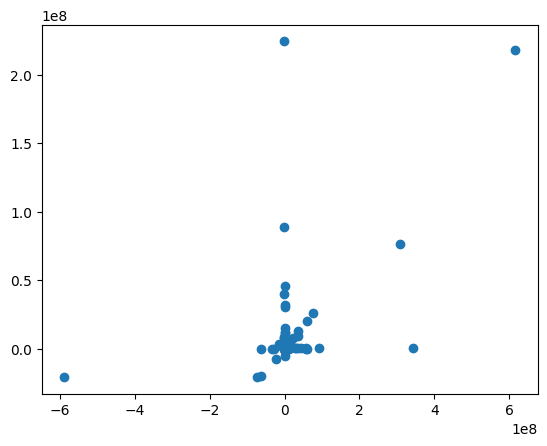

In [38]:
x=ind_fuel_demand_by_sector_100k[columns_in_both].mean()
y=ind_fuel_demand_by_sector_1k[columns_in_both].mean()
plt.scatter(x, y)